In [77]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from medlib.cstes import swot_dir, drifters_dir
from medlib.swot import browse_swot, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
dfs = browse_swot().reset_index()
dfs

,day,pass_number,cycle_number,file,time
0,2023-04-01,3,478,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-01 23:42:32.696536000
1,2023-04-02,3,479,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-02 23:33:10.425673088
2,2023-04-03,3,480,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-03 23:23:48.189185728
3,2023-04-04,3,481,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-04 23:14:25.904031360
4,2023-04-05,3,482,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-05 23:05:03.656492928
...,...,...,...,...,...
182,2023-07-05,16,573,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-07-05 19:33:50.331633280
183,2023-07-06,16,574,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-07-06 19:24:28.273369600
184,2023-07-07,16,575,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-07-07 19:15:06.145279168
185,2023-07-08,16,576,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-07-08 19:05:44.003893184


In [72]:
color = {
    'BIOSWOT: CARTHE': "firebrick",
    'FAST-SWOT: CARTHE':'darkred',
    'C-SWOT: CARTHE': "orange",
    'BIOSWOT: CODE': "green",
    'BIOSWOT: SVPOGS': "darkblue",
    'BIOSWOT: SVPSIO': "teal",
    'C-SWOT: SVP': "lightblue",
    'C-SWOT: SPOTTER': "yellow",
    'C-SWOT: MELODI': "hotpink",
    'FAST-SWOT: HEREON':'peru',
    'FAST-SWOT: OSMC':'violet',
}

lw=0.5
bbox = [-0.3, 11, 36.5, 44.5]

# One image
Une image par image swot

In [67]:
#DATA SELECTION
swath = 3

# SWOT
df3 = dfs.where(dfs.pass_number==int(3)).dropna()
dss = xr.open_dataset(df3.iloc[0].file)
dss['eta'] = dss.cvl_mean_dynamic_topography_cnes_cls_22 + dss.cvl_ocean_tide_fes_2022 + dss.duacs_ssha_karin_2_filtered

# DRIFTERS
time = pd.to_datetime(dss.time.mean().values).round('min')
#dt = pd.Timedelta('12h')#drifters points for whose the SWOT images is the nearest one (less precise)
dt = df3.time.diff().median() #drifters points for whose the SWOT images is the nearest one (more precise)
dr = xr.open_dataset(os.path.join(drifters_dir, 'L2', 'all_med_variational_1h_v0.nc'))
dr = dr.where(dr.gap_mask==1)
# Time selection
dr_ = dr.sel(datetime = slice(time-dt, time+dt))
# Under inside SWOT 
dr_ = add_mask_inside_swot(dss, dr_)
dr__ = dr_.where(dr_["inside_left"]+dr_["inside_right"])

/home1/datahome/mdemol/.miniconda3/envs/histenv2/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv2/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


In [69]:
figsize=10,10
lon=4
lat=39.3

/home1/datahome/mdemol/.miniconda3/envs/histenv2/lib/python3.9/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, out=out, **kwargs)
/home1/datahome/mdemol/.miniconda3/envs/histenv2/lib/python3.9/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, out=out, **kwargs)
/home1/datahome/mdemol/.miniconda3/envs/histenv2/lib/python3.9/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, out=out, **kwargs)
/home1/datahome/mdemol/.miniconda3/envs/histenv2/lib/python3.9/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, out=out, **kwargs)
/home1/datahome/mdemol/.miniconda3/envs/histenv2/lib/python3.9/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrin

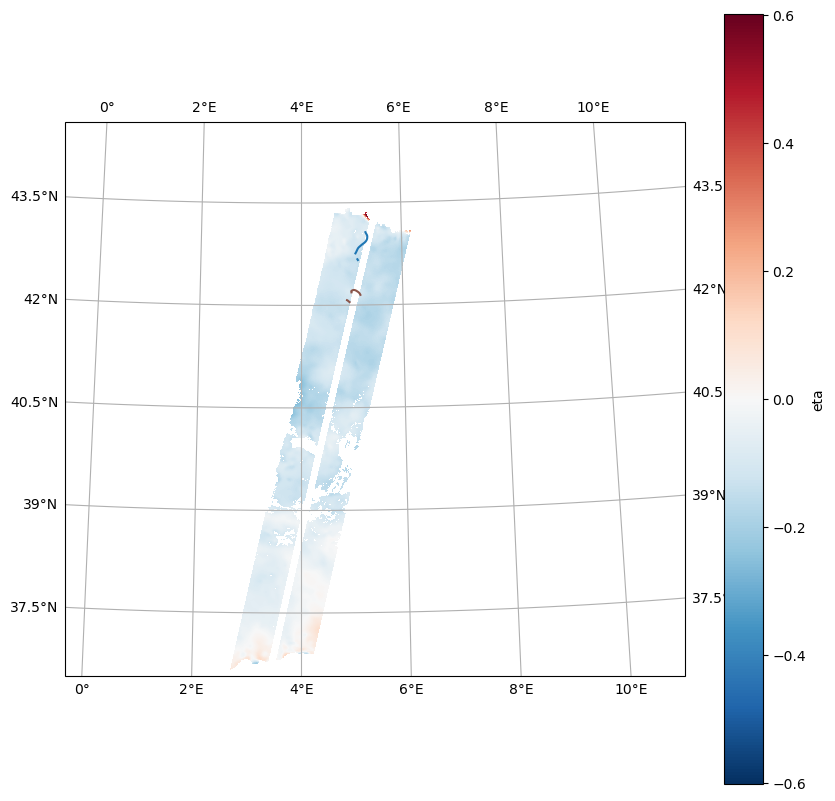

In [76]:
fig = plt.figure(figsize=figsize)
fig.patch.set_facecolor('white')#no transparancy in png
ax = fig.add_subplot(111, projection=ccrs.Orthographic(lon, lat))
ds_eta.plot(x='longitude', y='latitude', transform=crs, ax=ax)

for id in dr.drifter_id : 
    dr_ = dr__.sel(drifter_id=id)
    if np.all(dr_.longitude.notnull()):
        continue
    else :
        ax.plot(dr_.longitude, dr_.latitude, transform=crs)
gl = ax.gridlines(draw_labels=True,)
# ax.coastlines("50m")
ax.set_extent(bbox)